American put price 7.560314164168644
European put price 5.570493576937525
BS European put price 5.615510285238031


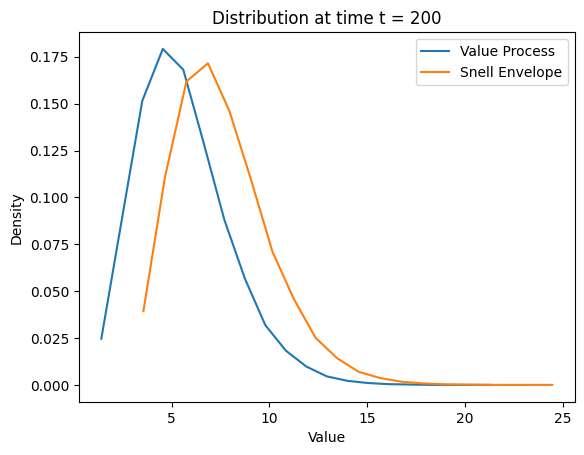

In [2]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

import numpy as np
import matplotlib.pyplot as plt

from GBM import ExactGBM
from Snell_Envelope import Snell_envelope
from BSpricesEU import BS



#### PARAMETERS #####

S0 = 100
r = 0.05
sigma = 0.2
T = 1

n = 2000        # time steps
N = 50000      # number of paths
Nbasis = 4

K = 105


##### SIMULATION of the SNELL ENVELOPE for VALUE PROCESS ######

V, Z = Snell_envelope(S0, T, r, sigma, n, K, N, Nbasis)


###### VISUALIZATION #######



####### PRICES #########

AM_PRICE = np.mean(Z[0])
EU_PRICE = np.mean(V[0])
BS_EU_PRICE = BS(S0, K, T, r, sigma)

print("American put price", AM_PRICE)
print("European put price", EU_PRICE)
print("BS European put price", BS_EU_PRICE)

##### DISTRIBUTIONS ######## 
TIME = n // 10
NormalizedTime=TIME/n

def plot_density(a, b, label1, label2, title):
    counts1, bins1 = np.histogram(a, bins=20, density=True)
    counts2, bins2 = np.histogram(b, bins=20, density=True)

    centers1 = 0.5 * (bins1[1:] + bins1[:-1])
    centers2 = 0.5 * (bins2[1:] + bins2[:-1])

    plt.figure()
    plt.plot(centers1, counts1, label=label1)
    plt.plot(centers2, counts2, label=label2)

    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.show()


plot_density(
    V[TIME],
    Z[TIME],
    "Value Process",
    "Snell Envelope",
    f"Distribution at time t = {TIME}"
)